
##  **ML Major Project - Intelligent Hybrid Profile-Based Matching & Recommendation System**

## Project Objective

The objective of this project is to develop an intelligent hybrid recommendation
system that identifies compatible professional and personal connections using:

- Natural Language Processing (NLP)
- Semantic text similarity
- MBTI-based personality compatibility
- Demographic/location information
- Machine Learning-based feedback learning

The system will initially calculate compatibility using multiple profile features
and will subsequently learn from user Accept/Reject feedback to improve future
recommendations.

### Dataset

A realistic synthetic dataset will be generated using Python. It contains
professional profiles, personal traits, MBTI personality types, interests,
free-text descriptions, and user interaction feedback.

In [1]:
# import required libraries

import pandas as pd
import numpy as np
import random
import re
import string
from datetime import datetime, timedelta

# Reproducibility  - If we run the same experiment again with the same code and same settings, we should get the same results.
random.seed(42)
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Dataset Schema

user_columns = [
    "user_id",
    "name",
    "age",
    "location",
    "profession",
    "experience_years",
    "professional_summary",
    "about_me",
    "mbti",
    "interests"
]

print("Number of required columns:", len(user_columns))
print("\nRequired columns:")

for i, column in enumerate(user_columns, start=1):
    print(f"{i}. {column}")

Number of required columns: 10

Required columns:
1. user_id
2. name
3. age
4. location
5. profession
6. experience_years
7. professional_summary
8. about_me
9. mbti
10. interests


In [3]:
# Datatypes and purpose

schema = pd.DataFrame({
    "Column": [
        "user_id",
        "name",
        "age",
        "location",
        "profession",
        "experience_years",
        "professional_summary",
        "about_me",
        "mbti",
        "interests"
    ],

    "Data Type": [
        "String",
        "String",
        "Integer",
        "String",
        "String",
        "Integer",
        "Text",
        "Text",
        "Categorical",
        "Text"
    ],

    "Purpose": [
        "Unique user identification",
        "User display name",
        "User age",
        "City or region",
        "Professional role",
        "Years of experience",
        "Career-focused description",
        "Personal description",
        "Personality type",
        "Personal interests"
    ]
})

display(schema)

,Column,Data Type,Purpose
0,user_id,String,Unique user identification
1,name,String,User display name
2,age,Integer,User age
3,location,String,City or region
4,profession,String,Professional role
5,experience_years,Integer,Years of experience
6,professional_summary,Text,Career-focused description
7,about_me,Text,Personal description
8,mbti,Categorical,Personality type
9,interests,Text,Personal interests


In [4]:
# Professions
professions = [
    "Software Engineer",
    "Data Scientist",
    "Data Analyst",
    "Machine Learning Engineer",
    "AI Engineer",
    "Business Analyst",
    "Product Manager",
    "UI/UX Designer",
    "Cybersecurity Analyst",
    "Cloud Engineer",
    "Researcher",
    "Digital Marketing Specialist",
    "Financial Analyst",
    "Entrepreneur",
    "Project Manager"
]

print("Number of professions:", len(professions))

Number of professions: 15


In [5]:
# Profession specific info
profession_data = {

    "Software Engineer": {
        "skills": [
            "Python",
            "Java",
            "SQL",
            "software development"
        ],
        "industries": [
            "SaaS",
            "FinTech",
            "EdTech",
            "E-commerce"
        ],
        "goals": [
            "building scalable software products",
            "developing reliable technology solutions",
            "growing into a senior engineering role"
        ]
    },

    "Data Scientist": {
        "skills": [
            "Python",
            "machine learning",
            "statistics",
            "data analysis"
        ],
        "industries": [
            "healthcare analytics",
            "FinTech",
            "retail analytics",
            "AI"
        ],
        "goals": [
            "developing predictive models",
            "solving real-world problems using data",
            "building intelligent analytical systems"
        ]
    },

    "Data Analyst": {
        "skills": [
            "SQL",
            "Python",
            "Excel",
            "data visualization"
        ],
        "industries": [
            "business analytics",
            "healthcare",
            "retail",
            "banking"
        ],
        "goals": [
            "turning data into useful business insights",
            "improving analytical decision-making",
            "growing into an advanced analytics role"
        ]
    },

    "Machine Learning Engineer": {
        "skills": [
            "Python",
            "machine learning",
            "Scikit-learn",
            "model deployment"
        ],
        "industries": [
            "AI",
            "SaaS",
            "healthcare technology",
            "FinTech"
        ],
        "goals": [
            "building production-ready machine learning systems",
            "developing intelligent applications",
            "working on practical AI solutions"
        ]
    },

    "AI Engineer": {
        "skills": [
            "Python",
            "deep learning",
            "NLP",
            "artificial intelligence"
        ],
        "industries": [
            "AI",
            "robotics",
            "EdTech",
            "healthcare technology"
        ],
        "goals": [
            "developing intelligent AI applications",
            "working on advanced artificial intelligence systems",
            "creating useful AI-powered products"
        ]
    },

    "Business Analyst": {
        "skills": [
            "SQL",
            "business analysis",
            "communication",
            "problem solving"
        ],
        "industries": [
            "banking",
            "consulting",
            "retail",
            "FinTech"
        ],
        "goals": [
            "connecting business requirements with technology",
            "improving organizational decision-making",
            "developing strategic analytical skills"
        ]
    },

    "Product Manager": {
        "skills": [
            "product strategy",
            "communication",
            "market research",
            "leadership"
        ],
        "industries": [
            "SaaS",
            "EdTech",
            "FinTech",
            "E-commerce"
        ],
        "goals": [
            "building user-focused digital products",
            "leading innovative technology initiatives",
            "developing strong product leadership skills"
        ]
    },

    "UI/UX Designer": {
        "skills": [
            "UI design",
            "UX research",
            "Figma",
            "prototyping"
        ],
        "industries": [
            "SaaS",
            "EdTech",
            "E-commerce",
            "creative technology"
        ],
        "goals": [
            "creating intuitive digital experiences",
            "designing accessible and user-friendly products",
            "growing as a product designer"
        ]
    },

    "Cybersecurity Analyst": {
        "skills": [
            "network security",
            "Python",
            "threat analysis",
            "security monitoring"
        ],
        "industries": [
            "cybersecurity",
            "banking",
            "FinTech",
            "cloud security"
        ],
        "goals": [
            "protecting digital systems from emerging threats",
            "developing expertise in cybersecurity",
            "working on secure technology infrastructure"
        ]
    },

    "Cloud Engineer": {
        "skills": [
            "AWS",
            "cloud computing",
            "Linux",
            "DevOps"
        ],
        "industries": [
            "SaaS",
            "cloud technology",
            "FinTech",
            "enterprise technology"
        ],
        "goals": [
            "designing scalable cloud infrastructure",
            "improving reliable technology operations",
            "developing advanced cloud engineering expertise"
        ]
    },

    "Researcher": {
        "skills": [
            "research",
            "Python",
            "data analysis",
            "technical writing"
        ],
        "industries": [
            "AI research",
            "healthcare",
            "education",
            "technology"
        ],
        "goals": [
            "conducting meaningful technical research",
            "developing new solutions to complex problems",
            "contributing to research-driven innovation"
        ]
    },

    "Digital Marketing Specialist": {
        "skills": [
            "content strategy",
            "SEO",
            "analytics",
            "social media"
        ],
        "industries": [
            "E-commerce",
            "media",
            "SaaS",
            "consumer technology"
        ],
        "goals": [
            "building data-driven marketing strategies",
            "growing digital brands",
            "combining creativity with analytics"
        ]
    },

    "Financial Analyst": {
        "skills": [
            "financial analysis",
            "Excel",
            "data analysis",
            "forecasting"
        ],
        "industries": [
            "banking",
            "FinTech",
            "investment",
            "corporate finance"
        ],
        "goals": [
            "improving financial decision-making",
            "developing expertise in financial analytics",
            "working with data-driven financial strategies"
        ]
    },

    "Entrepreneur": {
        "skills": [
            "business strategy",
            "leadership",
            "market research",
            "communication"
        ],
        "industries": [
            "technology",
            "SaaS",
            "FinTech",
            "EdTech"
        ],
        "goals": [
            "building innovative technology businesses",
            "turning ideas into useful products",
            "developing sustainable entrepreneurial ventures"
        ]
    },

    "Project Manager": {
        "skills": [
            "project management",
            "leadership",
            "communication",
            "planning"
        ],
        "industries": [
            "technology",
            "SaaS",
            "consulting",
            "enterprise"
        ],
        "goals": [
            "leading successful technology projects",
            "improving team collaboration and delivery",
            "developing strategic leadership capabilities"
        ]
    }
}

print("Profession knowledge base created successfully.")

Profession knowledge base created successfully.


In [6]:
# check profession knowledge base

print("Total professions:", len(profession_data))

print("\nExample: Data Scientist")
print("--------------------------------")

print("Skills:")
print(profession_data["Data Scientist"]["skills"])

print("\nIndustries:")
print(profession_data["Data Scientist"]["industries"])

print("\nCareer Goals:")
print(profession_data["Data Scientist"]["goals"])

Total professions: 15

Example: Data Scientist
--------------------------------
Skills:
['Python', 'machine learning', 'statistics', 'data analysis']

Industries:
['healthcare analytics', 'FinTech', 'retail analytics', 'AI']

Career Goals:
['developing predictive models', 'solving real-world problems using data', 'building intelligent analytical systems']


### **MBTI Personality Types**

MBTI (Myers-Briggs Type Indicator) classifies personalities into 16 types.

For this project, the types are broadly grouped as:

- **Analytical:** INTJ, INTP, ISTJ
- **Leadership:** ENTJ, ENFJ, ESTJ
- **Creative:** INFP, ENFP, ISFP
- **Social & Collaborative:** ESFJ, ESFP, ENFP
- **Practical & Adaptable:** ISTP, ESTP, ISFP
- **Thoughtful & Supportive:** INFJ, ISFJ

The MBTI type is used as a categorical feature for personality-based
compatibility matching.

In [7]:
# 4. MBTI PERSONALITY TYPES

mbti_types = [
    "INTJ", "INTP", "ENTJ", "ENTP",
    "INFJ", "INFP", "ENFJ", "ENFP",
    "ISTJ", "ISFJ", "ESTJ", "ESFJ",
    "ISTP", "ISFP", "ESTP", "ESFP"
]

print("Number of MBTI types:", len(mbti_types))
print("\nValid MBTI types:")

for mbti in mbti_types:
    print(mbti)

Number of MBTI types: 16

Valid MBTI types:
INTJ
INTP
ENTJ
ENTP
INFJ
INFP
ENFJ
ENFP
ISTJ
ISFJ
ESTJ
ESFJ
ISTP
ISFP
ESTP
ESFP


In [8]:
# MBTI Personality Traits
mbti_traits = {

    "INTJ": [
        "analytical",
        "strategic",
        "independent",
        "curious"
    ],

    "INTP": [
        "analytical",
        "curious",
        "innovative",
        "independent"
    ],

    "ENTJ": [
        "ambitious",
        "strategic",
        "decisive",
        "leadership-oriented"
    ],

    "ENTP": [
        "creative",
        "curious",
        "energetic",
        "innovative"
    ],

    "INFJ": [
        "empathetic",
        "thoughtful",
        "purpose-driven",
        "insightful"
    ],

    "INFP": [
        "creative",
        "empathetic",
        "idealistic",
        "open-minded"
    ],

    "ENFJ": [
        "empathetic",
        "collaborative",
        "supportive",
        "leadership-oriented"
    ],

    "ENFP": [
        "creative",
        "enthusiastic",
        "curious",
        "collaborative"
    ],

    "ISTJ": [
        "structured",
        "reliable",
        "practical",
        "detail-oriented"
    ],

    "ISFJ": [
        "supportive",
        "reliable",
        "organized",
        "empathetic"
    ],

    "ESTJ": [
        "organized",
        "decisive",
        "practical",
        "leadership-oriented"
    ],

    "ESFJ": [
        "supportive",
        "social",
        "organized",
        "collaborative"
    ],

    "ISTP": [
        "practical",
        "independent",
        "adaptable",
        "analytical"
    ],

    "ISFP": [
        "creative",
        "flexible",
        "empathetic",
        "independent"
    ],

    "ESTP": [
        "energetic",
        "practical",
        "adaptable",
        "social"
    ],

    "ESFP": [
        "enthusiastic",
        "social",
        "creative",
        "adaptable"
    ]
}

print("MBTI trait dictionary created.")

MBTI trait dictionary created.


In [9]:
# Test MBTI traits
print("INTJ traits:")
print(mbti_traits["INTJ"])

print("\nENFP traits:")
print(mbti_traits["ENFP"])

print("\nISTJ traits:")
print(mbti_traits["ISTJ"])

INTJ traits:
['analytical', 'strategic', 'independent', 'curious']

ENFP traits:
['creative', 'enthusiastic', 'curious', 'collaborative']

ISTJ traits:
['structured', 'reliable', 'practical', 'detail-oriented']


In [10]:
# work style options

work_styles = [
    "collaborative team environments",
    "independent work with room for experimentation",
    "structured environments with clear goals",
    "creative environments where ideas can be discussed openly",
    "problem-solving environments involving different perspectives"
]

print("Available work styles:")

for style in work_styles:
    print("-", style)

Available work styles:
- collaborative team environments
- independent work with room for experimentation
- structured environments with clear goals
- creative environments where ideas can be discussed openly
- problem-solving environments involving different perspectives


In [11]:
# Personal values
values = [
    "continuous learning",
    "meaningful work",
    "honest communication",
    "innovation",
    "reliability",
    "knowledge sharing",
    "personal growth",
    "helping others"
]

print("Available personal values:")

for value in values:
    print("-", value)

Available personal values:
- continuous learning
- meaningful work
- honest communication
- innovation
- reliability
- knowledge sharing
- personal growth
- helping others


In [12]:
#MBTI data validation
print(" MBTI VALIDATION\n")
print("Number of allowed MBTI types:", len(mbti_types))
print(
    "Number of MBTI types with trait definitions:",
    len(mbti_traits)
)
print("\nMissing trait definitions:")

missing_traits = [
    mbti for mbti in mbti_types
    if mbti not in mbti_traits
]
print(missing_traits)
print("\nInvalid MBTI keys:")

invalid_keys = [
    mbti for mbti in mbti_traits
    if mbti not in mbti_types
]
print(invalid_keys)
print("\nVALIDATION COMPLETE")

 MBTI VALIDATION

Number of allowed MBTI types: 16
Number of MBTI types with trait definitions: 16

Missing trait definitions:
[]

Invalid MBTI keys:
[]

VALIDATION COMPLETE


### Personal Interests

Users are assigned a small set of realistic interests such as technology,
research, entrepreneurship, design, fitness, reading, and travel.

These interests help create diverse personal profiles and provide additional
textual information for NLP-based similarity matching.

In [13]:
# Personal Interests
interests_list = [
    "artificial intelligence",
    "machine learning",
    "technology",
    "reading",
    "research",
    "entrepreneurship",
    "fitness",
    "photography",
    "music",
    "travel",
    "design",
    "finance",
    "startups",
    "coding",
    "public speaking",
    "writing",
    "volunteering",
    "meditation",
    "sports",
    "innovation"
]

print("Number of available interests:", len(interests_list))

Number of available interests: 20


##  Professional Summary Generation

The professional summary is generated from structured profile information
including profession, skills, industry, and career goals.

The generated text is designed to resemble a realistic professional profile
and will later be processed using NLP techniques for semantic similarity.

In [14]:
# Professional Summary Generation
def generate_professional_summary(profession):

    # Get information about the selected profession
    data = profession_data[profession]

    # Select 2 different skills
    skill1, skill2 = random.sample(data["skills"], 2)

    # Select one industry
    industry = random.choice(data["industries"])

    # Select one career goal
    goal = random.choice(data["goals"])

    # Different sentence structures
    templates = [

        (
            f"{profession} focused on {goal}. "
            f"Skilled in {skill1} and {skill2}, "
            f"with an interest in the {industry} industry."
        ),

        (
            f"Working as a {profession} with experience in "
            f"{skill1} and {skill2}. "
            f"My career goal is {goal}, particularly within {industry}."
        ),

        (
            f"{profession} interested in building practical solutions "
            f"in {industry}. Experienced with {skill1} and {skill2}, "
            f"and currently aiming toward {goal}."
        )
    ]

    # Randomly select one template
    return random.choice(templates)

In [15]:
# Test Professional Summary Generator
print("Example 1:")
print(generate_professional_summary("Data Scientist"))

print("\nExample 2:")
print(generate_professional_summary("Software Engineer"))

print("\nExample 3:")
print(generate_professional_summary("UI/UX Designer"))

Example 1:
Data Scientist focused on developing predictive models. Skilled in Python and data analysis, with an interest in the retail analytics industry.

Example 2:
Software Engineer interested in building practical solutions in SaaS. Experienced with Java and SQL, and currently aiming toward growing into a senior engineering role.

Example 3:
UI/UX Designer focused on creating intuitive digital experiences. Skilled in UI design and Figma, with an interest in the creative technology industry.


In [16]:
# Test all Professions
for profession in professions:
    print("\n" + "=" * 70)
    print("Profession:", profession)
    print(generate_professional_summary(profession))


Profession: Software Engineer
Software Engineer interested in building practical solutions in FinTech. Experienced with Python and software development, and currently aiming toward growing into a senior engineering role.

Profession: Data Scientist
Data Scientist interested in building practical solutions in FinTech. Experienced with Python and statistics, and currently aiming toward building intelligent analytical systems.

Profession: Data Analyst
Working as a Data Analyst with experience in data visualization and SQL. My career goal is growing into an advanced analytics role, particularly within banking.

Profession: Machine Learning Engineer
Working as a Machine Learning Engineer with experience in Python and model deployment. My career goal is developing intelligent applications, particularly within FinTech.

Profession: AI Engineer
AI Engineer focused on developing intelligent AI applications. Skilled in deep learning and Python, with an interest in the EdTech industry.

Profess

##  About Me Generation

The About Me section is generated using the user's MBTI traits, preferred
work style, personal values, and interests.

The generated text is designed to provide meaningful personal information
for NLP-based profile similarity while maintaining variation between users.

In [17]:
# About ME Generator
def generate_about_me(mbti, selected_interests):

    # Select two personality traits based on MBTI
    traits = random.sample(mbti_traits[mbti], 2)

    # Select one work style
    work_style = random.choice(work_styles)

    # Select one personal value
    value = random.choice(values)

    # Select two interests
    interest1, interest2 = selected_interests[:2]

    # Different sentence structures
    templates = [

        (
            f"I am {traits[0]} and {traits[1]}, and I enjoy working in "
            f"{work_style}. I value {value} and spend my free time exploring "
            f"{interest1} and {interest2}."
        ),

        (
            f"I enjoy learning, solving problems, and working in "
            f"{work_style}. I value {value} and have a strong interest in "
            f"{interest1} and {interest2}. I also enjoy exchanging ideas "
            f"with people from different backgrounds."
        ),

        (
            f"My personality is generally {traits[0]} and {traits[1]}. "
            f"I prefer {work_style} and believe in {value}. Outside work, "
            f"I enjoy {interest1}, {interest2}, and discovering new ideas."
        )
    ]

    # Select one template
    return random.choice(templates)

In [18]:
# Test about me generator
test_interests = [
    "artificial intelligence",
    "research",
    "startups"
]

print(generate_about_me("INTJ", test_interests))

I enjoy learning, solving problems, and working in collaborative team environments. I value knowledge sharing and have a strong interest in artificial intelligence and research. I also enjoy exchanging ideas with people from different backgrounds.


In [19]:
# Test Different Personalities
test_interests = [
    "technology",
    "photography",
    "travel"
]

for mbti in ["INTJ", "ENFP", "ISTJ", "ISFP"]:

    print("\n" + "=" * 70)
    print("MBTI:", mbti)
    print("Traits:", mbti_traits[mbti])
    print("About Me:")
    print(generate_about_me(mbti, test_interests))


MBTI: INTJ
Traits: ['analytical', 'strategic', 'independent', 'curious']
About Me:
I am independent and analytical, and I enjoy working in independent work with room for experimentation. I value knowledge sharing and spend my free time exploring technology and photography.

MBTI: ENFP
Traits: ['creative', 'enthusiastic', 'curious', 'collaborative']
About Me:
I enjoy learning, solving problems, and working in creative environments where ideas can be discussed openly. I value honest communication and have a strong interest in technology and photography. I also enjoy exchanging ideas with people from different backgrounds.

MBTI: ISTJ
Traits: ['structured', 'reliable', 'practical', 'detail-oriented']
About Me:
My personality is generally reliable and structured. I prefer problem-solving environments involving different perspectives and believe in reliability. Outside work, I enjoy technology, photography, and discovering new ideas.

MBTI: ISFP
Traits: ['creative', 'flexible', 'empathetic

In [20]:
# check generated text length
for mbti in mbti_types[:5]:
    text = generate_about_me(
        mbti,
        ["technology", "reading", "research"]
    )

    print("\nMBTI:", mbti)
    print("Word count:", len(text.split()))
    print("Text:", text)


MBTI: INTJ
Word count: 31
Text: I am strategic and independent, and I enjoy working in creative environments where ideas can be discussed openly. I value meaningful work and spend my free time exploring technology and reading.

MBTI: INTP
Word count: 30
Text: My personality is generally analytical and independent. I prefer independent work with room for experimentation and believe in personal growth. Outside work, I enjoy technology, reading, and discovering new ideas.

MBTI: ENTJ
Word count: 32
Text: My personality is generally ambitious and strategic. I prefer creative environments where ideas can be discussed openly and believe in helping others. Outside work, I enjoy technology, reading, and discovering new ideas.

MBTI: ENTP
Word count: 27
Text: My personality is generally energetic and innovative. I prefer collaborative team environments and believe in meaningful work. Outside work, I enjoy technology, reading, and discovering new ideas.

MBTI: INFJ
Word count: 36
Text: I enjoy 

## Generating complete user profiles


In [21]:
# List of first names
first_names = [
    "Aarav", "Aditya", "Arjun", "Rohan", "Rahul",
    "Karthikeya", "Vikram", "Nikhil", "Siddharth", "Varun",
    "Ananya", "Diya", "Ishita", "Kavya", "Meera",
    "Priya", "Sneha", "Aisha", "Neha", "Anika"
]

# List of last names
last_names = [
    "Sharma", "Reddy", "Patel", "Rao", "Verma",
    "Iyer", "Nair", "Gupta", "Mehta", "Singh",
    "Kumar", "Joshi", "Malhotra", "Das", "Chowdhury"
]

# Locations
locations = [
    "Hyderabad",
    "Bengaluru",
    "Chennai",
    "Mumbai",
    "Pune",
    "Delhi",
    "Kolkata",
    "Ahmedabad",
    "Jaipur",
    "Kochi"
]

def generate_unique_name(used_names):

    while True:
        first = random.choice(first_names)
        last = random.choice(last_names)
        name = f"{first} {last}"
        if name not in used_names:
            used_names.add(name)
            return name

In [22]:
# Generate 100 users

NUM_USERS = 100
users_data = []
used_names = set()

for i in range(1, NUM_USERS + 1):

    # Generate unique user ID
    user_id = f"U{i:03d}"

    # Generate unique name
    name = generate_unique_name(used_names)

    # Generate age
    age = random.randint(21, 40)

    # Select location
    location = random.choice(locations)

    # Select profession
    profession = random.choice(professions)

    # Generate realistic experience based on age
    max_experience = min(age - 21, 15)
    experience_years = random.randint(0, max_experience)

    # Select MBTI personality type
    mbti = random.choice(mbti_types)

    # Select three interests
    selected_interests = random.sample(interests_list, 3)

    # Generate professional summary
    professional_summary = generate_professional_summary(profession)

    # Generate About Me section
    about_me = generate_about_me(
        mbti,
        selected_interests
    )

    # Store the complete profile
    users_data.append({
        "user_id": user_id,
        "name": name,
        "age": age,
        "location": location,
        "profession": profession,
        "experience_years": experience_years,
        "professional_summary": professional_summary,
        "about_me": about_me,
        "mbti": mbti,
        "interests": ", ".join(selected_interests)
    })


# Convert the list into a Pandas DataFrame
users = pd.DataFrame(users_data)
print("Dataset generated successfully!")
print("Number of users:", len(users))

Dataset generated successfully!
Number of users: 100


## Inspect the Dataset

In [23]:
display(users.head())

,user_id,name,age,location,profession,experience_years,professional_summary,about_me,mbti,interests
0,U001,Kavya Patel,35,Hyderabad,Digital Marketing Specialist,14,Digital Marketing Specialist interested in bui...,My personality is generally reliable and struc...,ISTJ,"volunteering, entrepreneurship, innovation"
1,U002,Sneha Chowdhury,21,Kochi,Business Analyst,0,Business Analyst focused on developing strateg...,My personality is generally analytical and ind...,INTJ,"reading, finance, travel"
2,U003,Rahul Patel,36,Jaipur,Data Analyst,8,Data Analyst interested in building practical ...,"I am independent and creative, and I enjoy wor...",ISFP,"fitness, meditation, innovation"
3,U004,Ananya Sharma,39,Jaipur,Machine Learning Engineer,7,Machine Learning Engineer interested in buildi...,My personality is generally strategic and curi...,INTJ,"technology, machine learning, photography"
4,U005,Rahul Joshi,39,Kochi,UI/UX Designer,7,Working as a UI/UX Designer with experience in...,"I am adaptable and social, and I enjoy working...",ESFP,"coding, fitness, reading"


In [24]:
# Dataset size
print("Shape of dataset:", users.shape)

Shape of dataset: (100, 10)


In [25]:
# column names and datatypes
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   user_id               100 non-null    object
 1   name                  100 non-null    object
 2   age                   100 non-null    int64 
 3   location              100 non-null    object
 4   profession            100 non-null    object
 5   experience_years      100 non-null    int64 
 6   professional_summary  100 non-null    object
 7   about_me              100 non-null    object
 8   mbti                  100 non-null    object
 9   interests             100 non-null    object
dtypes: int64(2), object(8)
memory usage: 7.9+ KB


In [26]:
# check one complete profile
print("USER:", users.loc[0, "name"])
print("PROFESSION:", users.loc[0, "profession"])
print("MBTI:", users.loc[0, "mbti"])
print("INTERESTS:", users.loc[0, "interests"])

print("\nPROFESSIONAL SUMMARY:")
print(users.loc[0, "professional_summary"])

print("\nABOUT ME:")
print(users.loc[0, "about_me"])

USER: Kavya Patel
PROFESSION: Digital Marketing Specialist
MBTI: ISTJ
INTERESTS: volunteering, entrepreneurship, innovation

PROFESSIONAL SUMMARY:
Digital Marketing Specialist interested in building practical solutions in SaaS. Experienced with content strategy and analytics, and currently aiming toward combining creativity with analytics.

ABOUT ME:
My personality is generally reliable and structured. I prefer structured environments with clear goals and believe in honest communication. Outside work, I enjoy volunteering, entrepreneurship, and discovering new ideas.


In [27]:
print("-- DATA QUALITY REPORT--\n")

print("Number of users:", len(users))
print("\nMissing values:")
print(users.isnull().sum())
print("\nDuplicate rows:", users.duplicated().sum())
print("Duplicate user IDs:", users["user_id"].duplicated().sum())

-- DATA QUALITY REPORT--

Number of users: 100

Missing values:
user_id                 0
name                    0
age                     0
location                0
profession              0
experience_years        0
professional_summary    0
about_me                0
mbti                    0
interests               0
dtype: int64

Duplicate rows: 0
Duplicate user IDs: 0


In [28]:
# Validate MBTI

invalid_mbti = users[~users["mbti"].isin(mbti_types)]
print("Invalid MBTI records:", len(invalid_mbti))

if len(invalid_mbti) > 0:
    display(invalid_mbti)

Invalid MBTI records: 0


In [29]:
# Check Text Fields ; Our NLP model will depend heavily on professional_summary and about_me, so we need to make sure they aren't empty.
empty_professional = (
    users["professional_summary"].str.strip() == ""
).sum()

empty_about = (
    users["about_me"].str.strip() == ""
).sum()

print("Empty professional summaries:", empty_professional)
print("Empty About Me fields:", empty_about)

Empty professional summaries: 0
Empty About Me fields: 0


In [30]:
# Validate Age and Experience
invalid_age = (
    (users["age"] < 21) |
    (users["age"] > 40)
).sum()

invalid_experience = (
    (users["experience_years"] < 0)
).sum()

print("Invalid ages:", invalid_age)
print("Invalid experience values:", invalid_experience)

Invalid ages: 0
Invalid experience values: 0


In [31]:
print("-- FINAL VALIDATION --\n")

checks = {
    "100 users generated": len(users) == 100,
    "No missing values": users.isnull().sum().sum() == 0,
    "No duplicate rows": users.duplicated().sum() == 0,
    "No duplicate user IDs": users["user_id"].duplicated().sum() == 0,
    "All MBTI values valid": len(invalid_mbti) == 0,
    "No empty professional summaries": empty_professional == 0,
    "No empty About Me fields": empty_about == 0,
    "All ages valid": invalid_age == 0,
    "All experience values valid": invalid_experience == 0
}

for check, result in checks.items():
    print(f"{'PASS' if result else 'FAIL'} — {check}")

-- FINAL VALIDATION --

PASS — 100 users generated
PASS — No missing values
PASS — No duplicate rows
PASS — No duplicate user IDs
PASS — All MBTI values valid
PASS — No empty professional summaries
PASS — No empty About Me fields
PASS — All ages valid
PASS — All experience values valid


In [32]:
users.to_csv("users.csv", index=False)
print("users.csv saved successfully!")

users.csv saved successfully!


In [33]:
import os
print("File exists:", os.path.exists("users.csv"))
print("File size:", os.path.getsize("users.csv"), "bytes")

File exists: True
File size: 48543 bytes


In [34]:
from google.colab import files
files.download("users.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Creating feedback.csv
### Create an MBTI compatibility function

we'll use a project heuristic rather than claiming that MBTI scientifically predicts compatibility.

In [35]:
def calculate_mbti_score(mbti_a, mbti_b):

    if mbti_a == mbti_b:
        return 70

    # Complementary personality patterns
    complementary_pairs = {
        "INTJ": ["ENFP", "ENTP"],
        "INTP": ["ENTJ", "ENFJ"],
        "ENTJ": ["INTP", "INFP"],
        "ENTP": ["INTJ", "INFJ"],
        "INFJ": ["ENTP", "ESTP"],
        "INFP": ["ENTJ", "ENFJ"],
        "ENFJ": ["INFP", "INTP"],
        "ENFP": ["INTJ", "ISTJ"],
        "ISTJ": ["ENFP", "ESFP"],
        "ISFJ": ["ENTP", "ESTP"],
        "ESTJ": ["ISFP", "INFP"],
        "ESFJ": ["ISTP", "ISFP"],
        "ISTP": ["ESFJ", "ENFJ"],
        "ISFP": ["ESTJ", "ESFJ"],
        "ESTP": ["INFJ", "ISFJ"],
        "ESFP": ["ISTJ", "ISFJ"]
    }

    if mbti_b in complementary_pairs.get(mbti_a, []):
        return 100
    return 50

In [36]:
# Calculate structured similarity; we'll create another function that compares two users.
def calculate_structured_scores(user_a, user_b):

    # 1. Profession similarity
    if user_a["profession"] == user_b["profession"]:
        profession_score = 1.0
    else:
        profession_score = 0.0

    # 2. Interest similarity
    interests_a = set(user_a["interests"].split(", "))
    interests_b = set(user_b["interests"].split(", "))
    common_interests = interests_a.intersection(interests_b)
    total_interests = interests_a.union(interests_b)

    if len(total_interests) > 0:
        interest_score = len(common_interests) / len(total_interests)
    else:
        interest_score = 0.0

    # 3. MBTI compatibility
    mbti_score = calculate_mbti_score(
        user_a["mbti"],
        user_b["mbti"]
    ) / 100

    # 4. Location similarity
    if user_a["location"] == user_b["location"]:
        location_score = 1.0
    else:
        location_score = 0.0

    return profession_score, interest_score, mbti_score, location_score

In [37]:
# Test the function

user_a = users.iloc[0]
user_b = users.iloc[1]
scores = calculate_structured_scores(user_a, user_b)

print("Profession similarity:", scores[0])
print("Interest similarity:", round(scores[1], 2))
print("MBTI similarity:", scores[2])
print("Location similarity:", scores[3])

Profession similarity: 0.0
Interest similarity: 0.0
MBTI similarity: 0.5
Location similarity: 0.0


In [38]:
# Generating 8 Interactions per user
feedback_data = []
INTERACTIONS_PER_USER = 8
start_date = datetime(2026, 1, 1)

for _, user_a in users.iterrows():

    # Select users other than the current user
    other_users = users[
        users["user_id"] != user_a["user_id"]
    ]

    # Select 8 different possible matches
    selected_matches = other_users.sample(
        n=INTERACTIONS_PER_USER,
        random_state=random.randint(0, 100000)
    )

    # Hidden preference weights for this user
    profession_weight = random.uniform(0.30, 0.50)
    interest_weight = random.uniform(0.20, 0.35)
    mbti_weight = random.uniform(0.15, 0.30)
    location_weight = random.uniform(0.05, 0.20)

    # Normalize weights
    total_weight = (
        profession_weight +
        interest_weight +
        mbti_weight +
        location_weight
    )

    profession_weight /= total_weight
    interest_weight /= total_weight
    mbti_weight /= total_weight
    location_weight /= total_weight

    for _, user_b in selected_matches.iterrows():
        profession_score, interest_score, mbti_score, location_score = (
            calculate_structured_scores(user_a, user_b)
        )

        preference_score = (
            profession_weight * profession_score +
            interest_weight * interest_score +
            mbti_weight * mbti_score +
            location_weight * location_score
        )

        # Add behavioral randomness
        noise = random.uniform(-0.20, 0.20)

        final_preference = preference_score + noise

        # Accept when the overall preference is reasonably high
        action = 1 if final_preference >= 0.25 else 0

        timestamp = start_date + timedelta(
            days=random.randint(0, 180),
            hours=random.randint(0, 23),
            minutes=random.randint(0, 59)
        )

        feedback_data.append({
            "user_id": user_a["user_id"],
            "matched_user_id": user_b["user_id"],
            "action": action,
            "timestamp": timestamp
        })

feedback = pd.DataFrame(feedback_data)
print("Feedback dataset regenerated successfully!")
print("Number of feedback records:", len(feedback))

Feedback dataset regenerated successfully!
Number of feedback records: 800


In [39]:
print("-- FEEDBACK DATASET REPORT --\n")

print("Number of feedback records:", len(feedback))
print("Number of columns:", len(feedback.columns))

print("\nColumns:")
print(list(feedback.columns))

print("\nFirst 5 records:")
display(feedback.head())

-- FEEDBACK DATASET REPORT --

Number of feedback records: 800
Number of columns: 4

Columns:
['user_id', 'matched_user_id', 'action', 'timestamp']

First 5 records:


,user_id,matched_user_id,action,timestamp
0,U001,U081,1,2026-01-09 18:44:00
1,U001,U088,0,2026-01-05 14:20:00
2,U001,U061,0,2026-04-16 22:13:00
3,U001,U013,0,2026-06-06 15:55:00
4,U001,U082,1,2026-01-16 22:08:00


In [40]:
# Check missing values
print("Missing values:")
print(feedback.isnull().sum())

Missing values:
user_id            0
matched_user_id    0
action             0
timestamp          0
dtype: int64


In [41]:
# Validate results
valid_actions = feedback["action"].isin([0, 1])
print("Invalid action values:", (~valid_actions).sum())

Invalid action values: 0


In [42]:
# Check that users aren't matched with themselves
self_matches = (
    feedback["user_id"] == feedback["matched_user_id"]
).sum()
print("Self-matches:", self_matches)

Self-matches: 0


In [43]:
# Check interactions per user
interactions_per_user = feedback["user_id"].value_counts()
print("Minimum interactions by a user:",
      interactions_per_user.min())
print("Maximum interactions by a user:",
      interactions_per_user.max())
display(interactions_per_user.head(10))

Minimum interactions by a user: 8
Maximum interactions by a user: 8


,count
user_id,
U001,8
U002,8
U003,8
U004,8
U005,8
U006,8
U007,8
U008,8
U009,8


In [44]:
# Check Accept vs Reject distribution

action_counts = feedback["action"].value_counts()
print("Reject (0):", action_counts.get(0, 0))
print("Accept (1):", action_counts.get(1, 0))

Reject (0): 524
Accept (1): 276


In [45]:
print("\nAcceptance rate:",
      round(feedback["action"].mean() * 100, 2), "%")


Acceptance rate: 34.5 %


In [46]:
print("-- FINAL FEEDBACK VALIDATION --\n")

# 1. Number of records
print("Number of feedback records:", len(feedback))

# 2. Missing values
print("\nMissing values:")
print(feedback.isnull().sum())

# 3. Duplicate rows
print("\nDuplicate rows:", feedback.duplicated().sum())

# 4. Valid actions
print(
    "\nInvalid action values:",
    (~feedback["action"].isin([0, 1])).sum()
)

# 5. Self matches
self_matches = (
    feedback["user_id"] == feedback["matched_user_id"]
).sum()
print("Self-matches:", self_matches)

# 6. Interactions per user
interactions_per_user = feedback["user_id"].value_counts()
print(
    "Minimum interactions per user:",
    interactions_per_user.min())

print(
    "Maximum interactions per user:",
    interactions_per_user.max())

-- FINAL FEEDBACK VALIDATION --

Number of feedback records: 800

Missing values:
user_id            0
matched_user_id    0
action             0
timestamp          0
dtype: int64

Duplicate rows: 0

Invalid action values: 0
Self-matches: 0
Minimum interactions per user: 8
Maximum interactions per user: 8


In [47]:
feedback.to_csv("feedback.csv", index=False)
print("feedback.csv saved successfully!")

feedback.csv saved successfully!


In [48]:
from google.colab import files
files.download("feedback.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Exploratory Data Analysis (EDA)**

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
print("EDA libraries imported successfully.")

EDA libraries imported successfully.


In [50]:
sns.set_theme(style="whitegrid")
print("Plotting style configured.")

Plotting style configured.


In [51]:
# dataset overview
print("-- USERS DATASET --")
print("Rows:", users.shape[0])
print("Columns:", users.shape[1])

print("\nColumn names:")
print(list(users.columns))

print("\nData types:")
print(users.dtypes)

-- USERS DATASET --
Rows: 100
Columns: 10

Column names:
['user_id', 'name', 'age', 'location', 'profession', 'experience_years', 'professional_summary', 'about_me', 'mbti', 'interests']

Data types:
user_id                 object
name                    object
age                      int64
location                object
profession              object
experience_years         int64
professional_summary    object
about_me                object
mbti                    object
interests               object
dtype: object


In [52]:
# NumericalSummary
users.describe()

,age,experience_years
count,100.000000,100.000000
mean,30.930000,5.050000
std,5.474007,4.212475
min,21.000000,0.000000
25%,27.750000,1.000000
50%,31.000000,4.000000
75%,36.000000,8.000000
max,40.000000,15.000000


In [53]:
# MissingValues Overview

missing_values = users.isnull().sum()
print(missing_values)

user_id                 0
name                    0
age                     0
location                0
profession              0
experience_years        0
professional_summary    0
about_me                0
mbti                    0
interests               0
dtype: int64


In [54]:
# Duplicate Overview

print("Duplicate rows:", users.duplicated().sum())
print("Duplicate user IDs:", users["user_id"].duplicated().sum())

Duplicate rows: 0
Duplicate user IDs: 0


## Graph 1 — Age Distribution

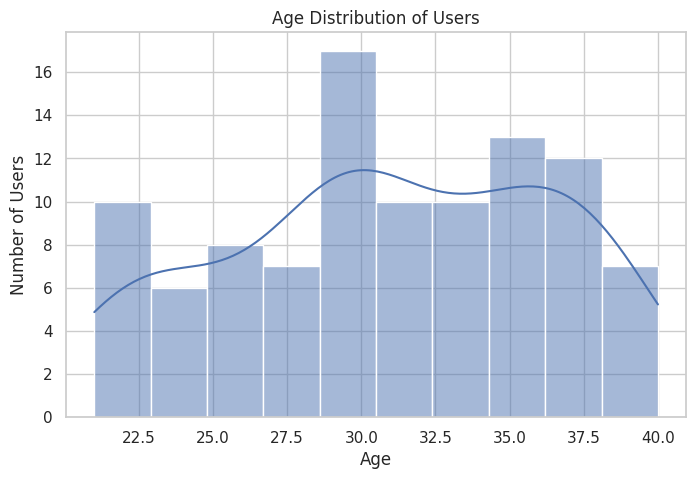

In [55]:
plt.figure(figsize=(8, 5))
sns.histplot(
    users["age"],
    bins=10,
    kde=True
)

plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()

## Observation
The age distribution shows how users are spread across the 21–40 age range. The dataset contains users from different professional stages, providing variation in the demographic profile.

## Graph 2 — Experience Distribution

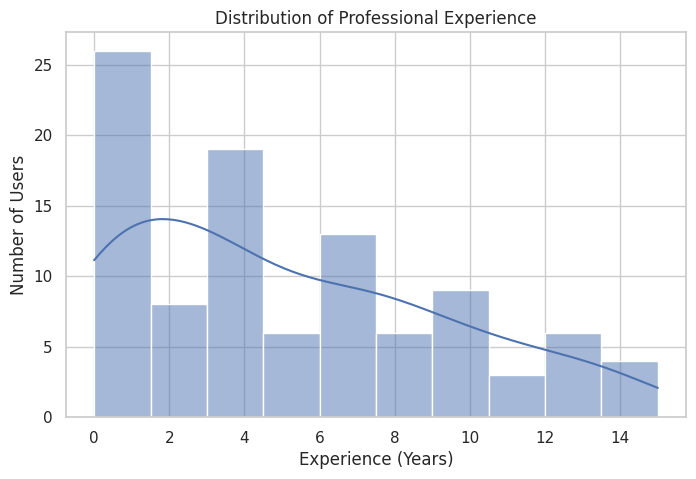

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(
    users["experience_years"],
    bins=10,
    kde=True
)

plt.title("Distribution of Professional Experience")
plt.xlabel("Experience (Years)")
plt.ylabel("Number of Users")
plt.show()

## Observation
The dataset contains users with different levels of professional experience, ranging from early-career users to users with several years of experience. This provides diversity in professional profiles.

## Graph 3 — Profession Distribution

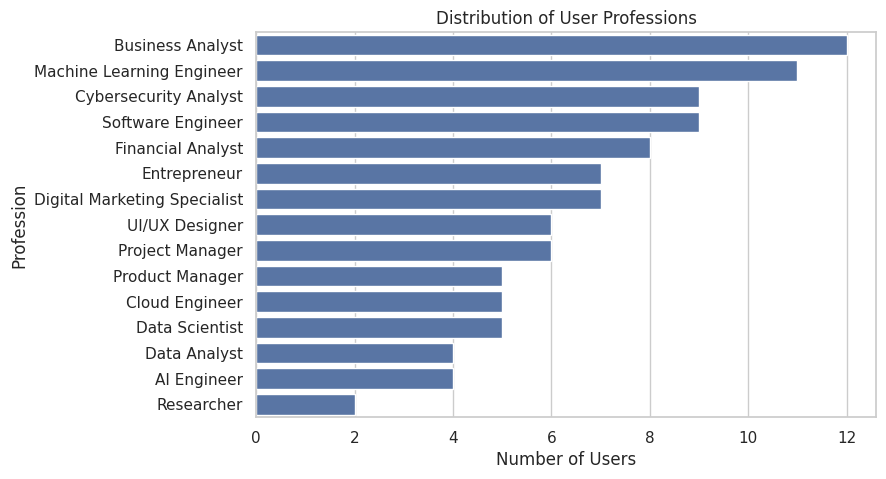

In [57]:
plt.figure(figsize=(8, 5))
profession_counts = users["profession"].value_counts()
sns.barplot(
    x=profession_counts.values,
    y=profession_counts.index
)

plt.title("Distribution of User Professions")
plt.xlabel("Number of Users")
plt.ylabel("Profession")
plt.show()

 ## Observation
 The dataset covers multiple professional roles rather than focusing on a single profession. This diversity is important because professional goals and skills are part of the profile-matching problem.

## Graph 4 — Location Distribution

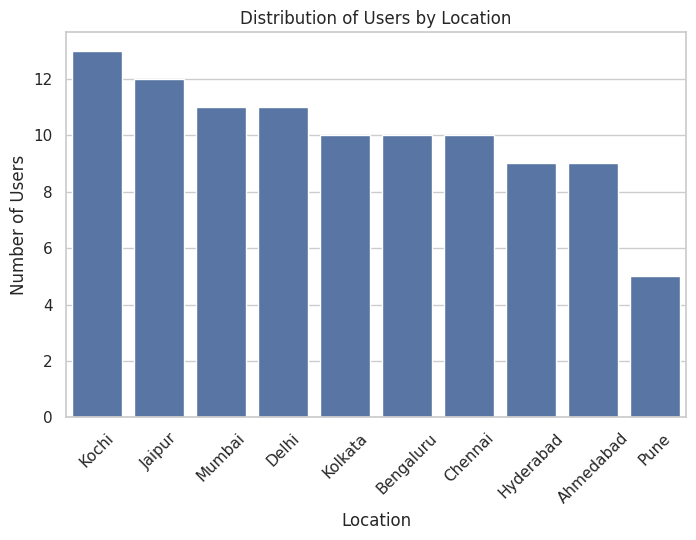

In [58]:
plt.figure(figsize=(8, 5))
location_counts = users["location"].value_counts()
sns.barplot(
    x=location_counts.index,
    y=location_counts.values
)

plt.title("Distribution of Users by Location")
plt.xlabel("Location")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

## Observation
Users are distributed across multiple locations. Location can therefore provide an additional demographic signal when calculating compatibility.

## Graph 5 — MBTI Distribution

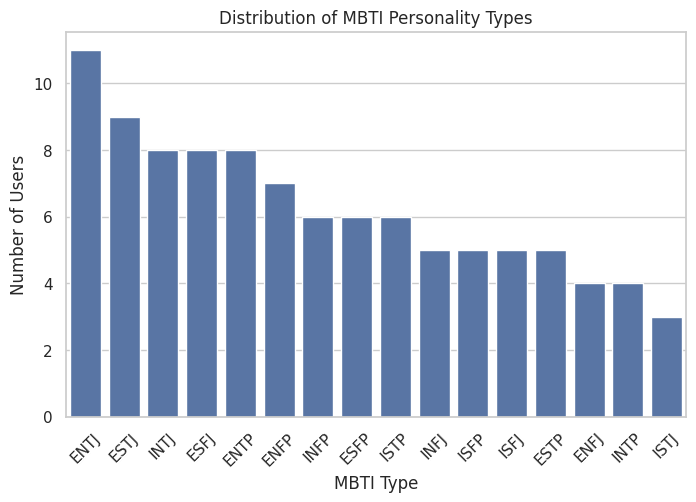

In [59]:
plt.figure(figsize=(8, 5))
mbti_counts = users["mbti"].value_counts()
sns.barplot(
    x=mbti_counts.index,
    y=mbti_counts.values
)

plt.title("Distribution of MBTI Personality Types")
plt.xlabel("MBTI Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

## Observation
The dataset contains multiple MBTI personality types, providing variation for the rule-based personality compatibility component.

## Graph 6 — Profession vs MBTI

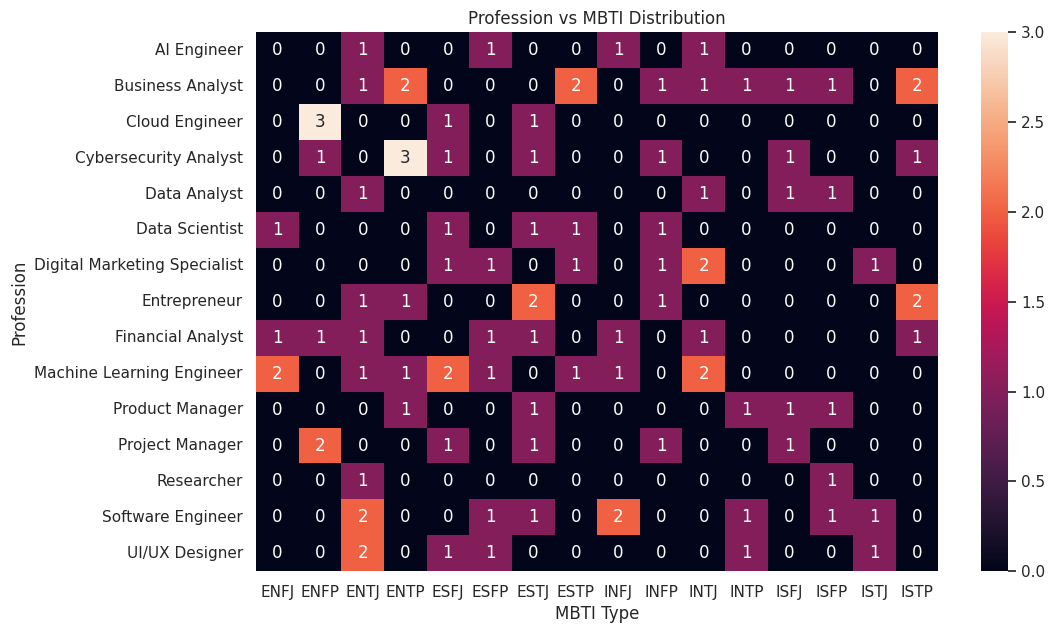

In [60]:
plt.figure(figsize=(11, 7))
profession_mbti = pd.crosstab(
    users["profession"],
    users["mbti"]
)

sns.heatmap(
    profession_mbti,
    annot=True,
    fmt="d"
)

plt.title("Profession vs MBTI Distribution")
plt.xlabel("MBTI Type")
plt.ylabel("Profession")
plt.show()

## Observation
The heatmap shows how MBTI types are distributed across different professions. The variation helps prevent the dataset from associating every profession with only one personality type.

## Graph 7 — Professional Summary Length

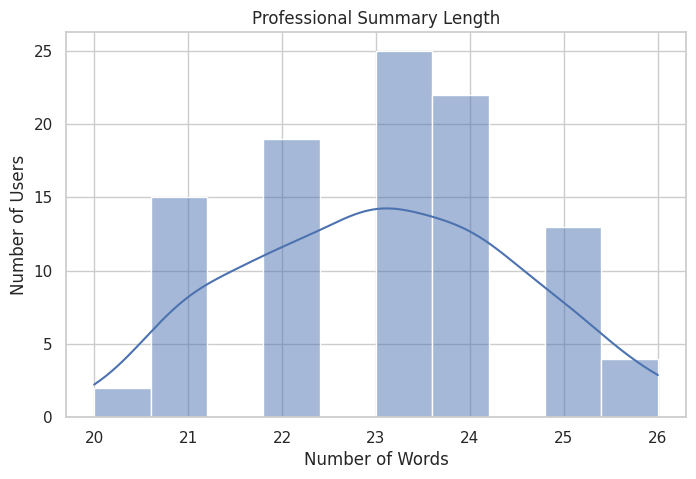

In [61]:
users["professional_summary_words"] = (
    users["professional_summary"]
    .str.split()
    .str.len()
)

plt.figure(figsize=(8, 5))
sns.histplot(
    users["professional_summary_words"],
    bins=10,
    kde=True
)

plt.title("Professional Summary Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Users")
plt.show()

## Observation
The professional summaries contain multiple words rather than extremely short descriptions, providing sufficient textual information for NLP-based similarity analysis.

## Graph 8 — About Me Length

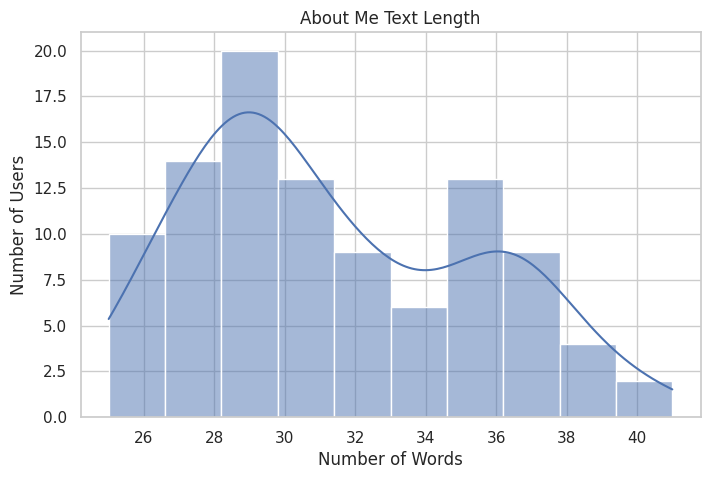

In [62]:
users["about_me_words"] = (
    users["about_me"]
    .str.split()
    .str.len()
)
plt.figure(figsize=(8, 5))

sns.histplot(
    users["about_me_words"],
    bins=10,
    kde=True
)

plt.title("About Me Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Users")
plt.show()

## Observation
The About Me fields contain meaningful personal descriptions involving personality, work style, values, and interests. This provides textual information that can be used by the NLP similarity component.

## Graph 9 — Age vs Experience

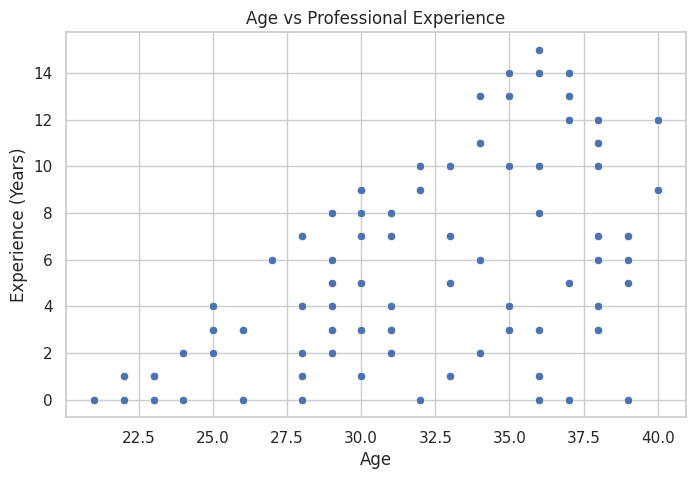

In [63]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=users,
    x="age",
    y="experience_years"
)

plt.title("Age vs Professional Experience")
plt.xlabel("Age")
plt.ylabel("Experience (Years)")
plt.show()

## Observation
The scatter plot shows the relationship between age and professional experience. The generated dataset generally maintains a logical relationship where older users can have greater professional experience.

This is also a useful synthetic-data quality check.

## Graph 10 — Accept vs Reject Feedback

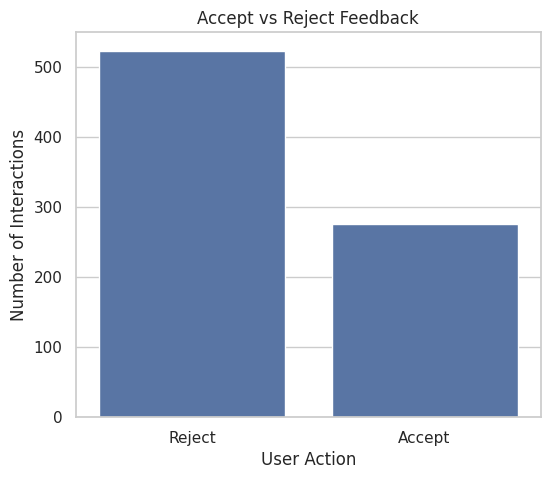

In [64]:
plt.figure(figsize=(6, 5))
feedback_counts = feedback["action"].map({
    0: "Reject",
    1: "Accept"
}).value_counts()

sns.barplot(
    x=feedback_counts.index,
    y=feedback_counts.values
)

plt.title("Accept vs Reject Feedback")
plt.xlabel("User Action")
plt.ylabel("Number of Interactions")
plt.show()

## Observation
The feedback dataset contains both accepted and rejected interactions, with more rejection events than acceptance events. This provides both positive and negative examples for the feedback-learning component.

## Acceptance by Profession Graph

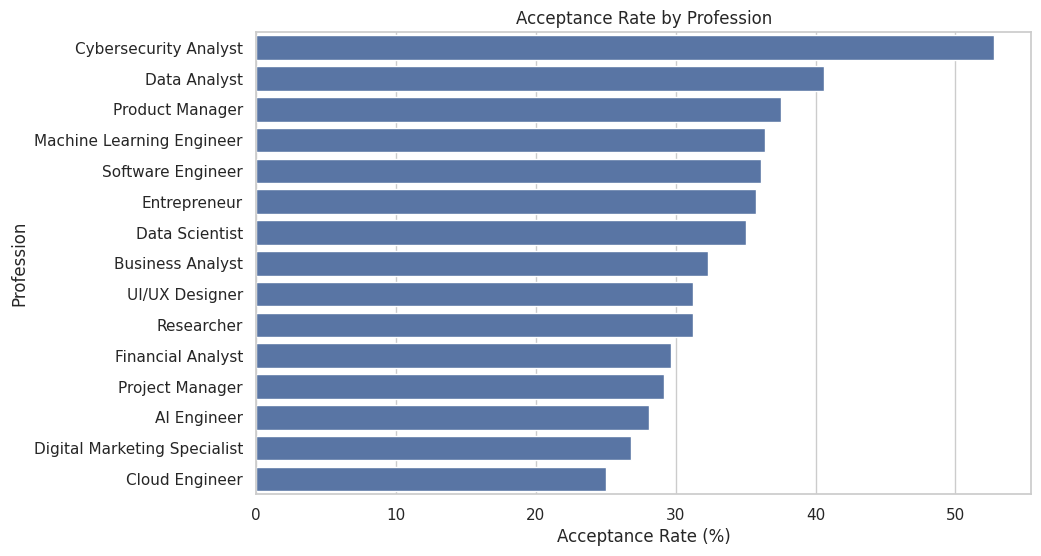

In [65]:
feedback_with_profession = feedback.merge(
    users[["user_id", "profession"]],
    on="user_id",
    how="left"
)

profession_acceptance = (
    feedback_with_profession
    .groupby("profession")["action"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=profession_acceptance.values,
    y=profession_acceptance.index
)

plt.title("Acceptance Rate by Profession")
plt.xlabel("Acceptance Rate (%)")
plt.ylabel("Profession")
plt.show()

## Observation
Acceptance rates vary across professions in the synthetic feedback data. This indicates that professional characteristics can influence simulated user preferences and provides useful information for the later feedback-learning stage.

## **NLP & Text Similarity**

In [66]:
# Prepare Text for NLP
# combine text fields
users["profile_text"] = (
    users["professional_summary"] + " " +
    users["about_me"] + " " +
    users["interests"]
)

display(
    users[
        [
            "user_id",
            "professional_summary",
            "about_me",
            "interests",
            "profile_text"
        ]
    ].head()
)

,user_id,professional_summary,about_me,interests,profile_text
0,U001,Digital Marketing Specialist interested in bui...,My personality is generally reliable and struc...,"volunteering, entrepreneurship, innovation",Digital Marketing Specialist interested in bui...
1,U002,Business Analyst focused on developing strateg...,My personality is generally analytical and ind...,"reading, finance, travel",Business Analyst focused on developing strateg...
2,U003,Data Analyst interested in building practical ...,"I am independent and creative, and I enjoy wor...","fitness, meditation, innovation",Data Analyst interested in building practical ...
3,U004,Machine Learning Engineer interested in buildi...,My personality is generally strategic and curi...,"technology, machine learning, photography",Machine Learning Engineer interested in buildi...
4,U005,Working as a UI/UX Designer with experience in...,"I am adaptable and social, and I enjoy working...","coding, fitness, reading",Working as a UI/UX Designer with experience in...


## Text preprocessing

In [67]:
import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [68]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Lemmatization -Converts related word forms toward a common base form.

print("Text preprocessing tools ready.")

Text preprocessing tools ready.


In [69]:
# Create the cleaning function
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Split text into individual words
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            word = lemmatizer.lemmatize(word)
            cleaned_words.append(word)

    # Join words back into a sentence
    return " ".join(cleaned_words)

In [70]:
# Test the cleaning function
sample_text = users.loc[0, "profile_text"]
print("ORIGINAL TEXT:")
print(sample_text)

print("\nCLEANED TEXT:")
print(clean_text(sample_text))

ORIGINAL TEXT:
Digital Marketing Specialist interested in building practical solutions in SaaS. Experienced with content strategy and analytics, and currently aiming toward combining creativity with analytics. My personality is generally reliable and structured. I prefer structured environments with clear goals and believe in honest communication. Outside work, I enjoy volunteering, entrepreneurship, and discovering new ideas. volunteering, entrepreneurship, innovation

CLEANED TEXT:
digital marketing specialist interested building practical solution saas experienced content strategy analytics currently aiming toward combining creativity analytics personality generally reliable structured prefer structured environment clear goal believe honest communication outside work enjoy volunteering entrepreneurship discovering new idea volunteering entrepreneurship innovation


In [71]:
# Clean all user profiles
users["cleaned_profile_text"] = users["profile_text"].apply(clean_text)
display(
    users[
        [
            "user_id",
            "profile_text",
            "cleaned_profile_text"
        ]
    ].head()
)

,user_id,profile_text,cleaned_profile_text
0,U001,Digital Marketing Specialist interested in bui...,digital marketing specialist interested buildi...
1,U002,Business Analyst focused on developing strateg...,business analyst focused developing strategic ...
2,U003,Data Analyst interested in building practical ...,data analyst interested building practical sol...
3,U004,Machine Learning Engineer interested in buildi...,machine learning engineer interested building ...
4,U005,Working as a UI/UX Designer with experience in...,working uiux designer experience ui design fig...


In [72]:
# Check the cleaned text
print("Missing cleaned text:",
      users["cleaned_profile_text"].isnull().sum())

print(
    "Empty cleaned text:",
    (users["cleaned_profile_text"].str.strip() == "").sum()
)

Missing cleaned text: 0
Empty cleaned text: 0


## **TF-IDF Vectorization**
TF-IDF = Term Frequency × Inverse Document Frequency

TF-IDF converts each user's cleaned profile into a numerical vector.

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer
print("TF-IDF vectorizer imported successfully.")

TF-IDF vectorizer imported successfully.


In [74]:
# Create the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000
)
print("TF-IDF vectorizer created.")

TF-IDF vectorizer created.


In [75]:
# Convert profiles into numerical vectors
tfidf_matrix = tfidf_vectorizer.fit_transform(
    users["cleaned_profile_text"]
)

print("TF-IDF transformation completed.")
print("Matrix shape:", tfidf_matrix.shape)

TF-IDF transformation completed.
Matrix shape: (100, 227)


In [76]:
# See the vocabulary
feature_names = tfidf_vectorizer.get_feature_names_out()
print("Number of vocabulary features:", len(feature_names))
print("\nFirst 30 features:")
print(feature_names[:30])

Number of vocabulary features: 227

First 30 features:
['accessible' 'adaptable' 'advanced' 'ai' 'aiming' 'aipowered' 'also'
 'ambitious' 'analysis' 'analyst' 'analytical' 'analytics' 'application'
 'artificial' 'aws' 'background' 'banking' 'believe' 'brand' 'building'
 'business' 'capability' 'career' 'clear' 'cloud' 'coding' 'collaboration'
 'collaborative' 'combining' 'communication']


In [77]:
# See the numerical representation
first_user_vector = tfidf_matrix[0].toarray()
print("Vector shape:", first_user_vector.shape)
print("\nFirst 20 TF-IDF values:")
print(first_user_vector[0][:20])

Vector shape: (1, 227)

First 20 TF-IDF values:
[0.         0.         0.         0.         0.09963948 0.
 0.         0.         0.         0.         0.         0.34269782
 0.         0.         0.         0.         0.         0.10959038
 0.         0.09020846]


In [78]:
# Convert the matrix to a DataFrame
tfidf_sample = pd.DataFrame(
    tfidf_matrix[:5].toarray(),
    columns=feature_names
)
display(tfidf_sample.iloc[:, :10])

,accessible,adaptable,advanced,ai,aiming,aipowered,also,ambitious,analysis,analyst
0,0.000000,0.000000,0.0,0.0,0.099639,0.0,0.0,0.0,0.000000,0.000000
1,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.145532,0.120433
2,0.000000,0.000000,0.0,0.0,0.120660,0.0,0.0,0.0,0.000000,0.130840
3,0.000000,0.000000,0.0,0.0,0.099688,0.0,0.0,0.0,0.000000,0.000000
4,0.241227,0.188959,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000


In [79]:
# Check that TF-IDF worked
print("Number of users:", tfidf_matrix.shape[0])
print("Number of features:", tfidf_matrix.shape[1])

Number of users: 100
Number of features: 227


## **Cosine Similarity**

Cosine similarity measures how similar two vectors are based on their direction.

For our project:

1 → highly similar
0 → very different

In [80]:
from sklearn.metrics.pairwise import cosine_similarity
print("Cosine similarity imported successfully.")

Cosine similarity imported successfully.


In [81]:
# Calculate similarity between all users
similarity_matrix = cosine_similarity(tfidf_matrix)
print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (100, 100)


In [82]:
# Compare two users
user_a = 0
user_b = 1
similarity_score = similarity_matrix[user_a, user_b]

print("User 1:", users.loc[user_a, "user_id"])
print("User 2:", users.loc[user_b, "user_id"])
print("Cosine similarity:", round(similarity_score, 3))

User 1: U001
User 2: U002
Cosine similarity: 0.128


In [83]:
# Convert it to a percentage
text_similarity_percentage = similarity_score * 100
print(
    "Text similarity:",
    round(text_similarity_percentage, 2),
    "%"
)

Text similarity: 12.79 %


In [84]:
# Find the most textually similar users
user_index = 0
similarities = similarity_matrix[user_index]
similar_users = pd.DataFrame({
    "user_id": users["user_id"],
    "name": users["name"],
    "profession": users["profession"],
    "mbti": users["mbti"],
    "text_similarity": similarities
})

similar_users = similar_users[
    similar_users["user_id"] != users.loc[user_index, "user_id"]
]

similar_users = similar_users.sort_values(
    by="text_similarity",
    ascending=False
)
display(similar_users.head(5))

,user_id,name,profession,mbti,text_similarity
16,U017,Neha Rao,Digital Marketing Specialist,INTJ,0.578977
98,U099,Aditya Sharma,Digital Marketing Specialist,ESFP,0.484532
10,U011,Varun Patel,Digital Marketing Specialist,INTJ,0.450586
82,U083,Aisha Iyer,Digital Marketing Specialist,INFP,0.430822
24,U025,Nikhil Verma,Software Engineer,ESTJ,0.352066


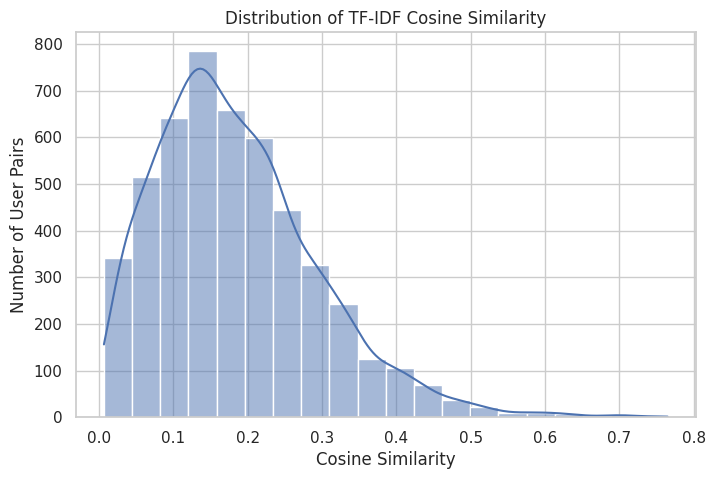

In [85]:
# Visualize similarity distribution
upper_triangle = similarity_matrix[
    np.triu_indices_from(similarity_matrix, k=1)
]
plt.figure(figsize=(8, 5))
sns.histplot(
    upper_triangle,
    bins=20,
    kde=True
)

plt.title("Distribution of TF-IDF Cosine Similarity")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of User Pairs")
plt.show()

## Observation
The cosine similarity distribution shows the range of textual similarity between different user profiles. Most user pairs have moderate or low similarity, while a smaller number of pairs show stronger textual similarity. This indicates that TF-IDF can distinguish profiles based on their textual characteristics.

In [86]:
# Create a reusable similarity function
def get_text_similarity(user_id_a, user_id_b):
    index_a = users.index[
        users["user_id"] == user_id_a
    ][0]

    index_b = users.index[
        users["user_id"] == user_id_b
    ][0]
    score = similarity_matrix[index_a, index_b]
    return score * 100

In [87]:
score = get_text_similarity("U001", "U002")
print("Text similarity:", round(score, 2), "%")

Text similarity: 12.79 %


## **MBTI Matching**

The project requires personality compatibility as one component of the final score.

Our rule is:

Same MBTI → 70/100
Complementary MBTI pair → 100/100
Other combinations → 50/100

This is a project heuristic, not a scientifically validated personality-compatibility measure.

In [88]:
# Test the MBTI scoring

print("Same MBTI:", calculate_mbti_score("INTJ", "INTJ"))
print("Complementary MBTI:", calculate_mbti_score("INTJ", "ENFP"))
print("Other MBTI:", calculate_mbti_score("INTJ", "ISTP"))

Same MBTI: 70
Complementary MBTI: 100
Other MBTI: 50


In [89]:
# Create a user-to-user MBTI function ; This lets us give two actual User IDs and get their MBTI compatibility.

def get_mbti_score(user_id_a, user_id_b):
    user_a = users[users["user_id"] == user_id_a].iloc[0]
    user_b = users[users["user_id"] == user_id_b].iloc[0]

    score = calculate_mbti_score(
        user_a["mbti"],
        user_b["mbti"]
    )
    return score

In [90]:
# Test it
mbti_score = get_mbti_score("U001", "U002")
print("User 1 MBTI:", users.loc[users["user_id"] == "U001", "mbti"].iloc[0])
print("User 2 MBTI:", users.loc[users["user_id"] == "U002", "mbti"].iloc[0])
print("MBTI Compatibility:", mbti_score, "%")

User 1 MBTI: ISTJ
User 2 MBTI: INTJ
MBTI Compatibility: 50 %


## Location Matching

In [91]:
#  Location Compatibility

def get_location_score(user_id_a, user_id_b):
    user_a = users[users["user_id"] == user_id_a].iloc[0]
    user_b = users[users["user_id"] == user_id_b].iloc[0]

    if user_a["location"] == user_b["location"]:
        return 100
    else:
        return 30

In [92]:
# test it
location_score = get_location_score("U001", "U002")
print(
    "User 1 Location:",
    users.loc[users["user_id"] == "U001", "location"].iloc[0]
)
print(
    "User 2 Location:",
    users.loc[users["user_id"] == "U002", "location"].iloc[0]
)
print("Location Compatibility:", location_score, "%")

User 1 Location: Hyderabad
User 2 Location: Kochi
Location Compatibility: 30 %


## Hybrid Compatibility Score
Final Score = (Text × 0.50) + (MBTI × 0.30) + (Location × 0.20)

In [93]:
# Create the hybrid scoring function

TEXT_WEIGHT = 0.50
MBTI_WEIGHT = 0.30
LOCATION_WEIGHT = 0.20

def calculate_hybrid_score(user_id_a, user_id_b):
    text_score = get_text_similarity(user_id_a, user_id_b)
    mbti_score = get_mbti_score(user_id_a, user_id_b)
    location_score = get_location_score(user_id_a, user_id_b)

    final_score = (
        TEXT_WEIGHT * text_score +
        MBTI_WEIGHT * mbti_score +
        LOCATION_WEIGHT * location_score
    )

    return {
        "text_score": text_score,
        "mbti_score": mbti_score,
        "location_score": location_score,
        "final_score": final_score
    }

In [94]:
# Test with U001 and U002

result = calculate_hybrid_score("U001", "U002")
print("========== HYBRID COMPATIBILITY ==========")
print("User 1: U001")
print("User 2: U002")
print("------------------------------------------")
print("Text Similarity:", round(result["text_score"], 2), "%")
print("MBTI Compatibility:", result["mbti_score"], "%")
print("Location Compatibility:", result["location_score"], "%")
print("------------------------------------------")
print("Final Compatibility Score:",
      round(result["final_score"], 2), "%")

========== HYBRID COMPATIBILITY ==========
User 1: U001
User 2: U002
------------------------------------------
Text Similarity: 12.79 %
MBTI Compatibility: 50 %
Location Compatibility: 30 %
------------------------------------------
Final Compatibility Score: 27.39 %


## Prepare Feedback Data for ML

In [95]:
#Create ML Features from Feedback

feedback_ml = feedback.copy()
feedback_ml["text_score"] = feedback_ml.apply(
    lambda row: get_text_similarity(
        row["user_id"],
        row["matched_user_id"]
    ),
    axis=1
)

feedback_ml["mbti_score"] = feedback_ml.apply(
    lambda row: get_mbti_score(
        row["user_id"],
        row["matched_user_id"]
    ),
    axis=1
)

feedback_ml["location_score"] = feedback_ml.apply(
    lambda row: get_location_score(
        row["user_id"],
        row["matched_user_id"]
    ),
    axis=1
)

feedback_ml.head()

,user_id,matched_user_id,action,timestamp,text_score,mbti_score,location_score
0,U001,U081,1,2026-01-09 18:44:00,11.344290,100,30
1,U001,U088,0,2026-01-05 14:20:00,7.253510,50,30
2,U001,U061,0,2026-04-16 22:13:00,2.829067,50,30
3,U001,U013,0,2026-06-06 15:55:00,12.801028,50,30
4,U001,U082,1,2026-01-16 22:08:00,1.707694,50,30


In [96]:
# check the new dataset
print("Feedback ML dataset shape:", feedback_ml.shape)
print("\nColumns:")
print(feedback_ml.columns.tolist())
print("\nFirst 5 records:")
display(feedback_ml.head())

Feedback ML dataset shape: (800, 7)

Columns:
['user_id', 'matched_user_id', 'action', 'timestamp', 'text_score', 'mbti_score', 'location_score']

First 5 records:


,user_id,matched_user_id,action,timestamp,text_score,mbti_score,location_score
0,U001,U081,1,2026-01-09 18:44:00,11.344290,100,30
1,U001,U088,0,2026-01-05 14:20:00,7.253510,50,30
2,U001,U061,0,2026-04-16 22:13:00,2.829067,50,30
3,U001,U013,0,2026-06-06 15:55:00,12.801028,50,30
4,U001,U082,1,2026-01-16 22:08:00,1.707694,50,30


In [97]:
# Check whether the features are valid
print("Missing values:")
print(feedback_ml[
    ["text_score", "mbti_score", "location_score", "action"]
].isnull().sum())

print("\nAction distribution:")
print(feedback_ml["action"].value_counts())

Missing values:
text_score        0
mbti_score        0
location_score    0
action            0
dtype: int64

Action distribution:
action
0    524
1    276
Name: count, dtype: int64


## Train the ML Feedback Model
 we train a Logistic Regression model.

The model will learn the relationship:

Text Score + MBTI Score + Location Score → Accept / Reject

In [98]:
# Select ML Features

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

X = feedback_ml[
    ["text_score", "mbti_score", "location_score"]
]
y = feedback_ml["action"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (800, 3)
Target shape: (800,)


In [99]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 640
Testing samples: 160


In [100]:
# Train Logistic Regression

feedback_model = LogisticRegression(
    max_iter=1000
)
feedback_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [101]:
# Predict Accept/Reject
y_pred = feedback_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]


In [102]:
# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 70.0 %


In [103]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       105
           1       0.62      0.33      0.43        55

    accuracy                           0.70       160
   macro avg       0.67      0.61      0.61       160
weighted avg       0.68      0.70      0.67       160



In [120]:
# Improve Logistic Regression for Class Imbalance

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)
balanced_pred = balanced_model.predict(X_test)
balanced_accuracy = accuracy_score(
    y_test,
    balanced_pred
)

print("--- BALANCED LOGISTIC REGRESSION ---")
print("Accuracy:", round(balanced_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        balanced_pred
    )
)

--- BALANCED LOGISTIC REGRESSION ---
Accuracy: 68.75 %

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.67      0.74       105
           1       0.53      0.73      0.62        55

    accuracy                           0.69       160
   macro avg       0.68      0.70      0.68       160
weighted avg       0.72      0.69      0.70       160



In [121]:
# Select Final Feedback Model
feedback_model_final = balanced_model

print("Final feedback model selected:")
print("Balanced Logistic Regression")

Final feedback model selected:
Balanced Logistic Regression


In [104]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[94 11]
 [37 18]]


In [122]:
# Learn Personalized Weights for One User

def learn_user_weights(user_id):
    # Get this user's feedback history
    user_feedback = feedback_ml[
        feedback_ml["user_id"] == user_id
    ].copy()

    # Start with our original hybrid weights
    weights = np.array([0.50, 0.30, 0.20])

    # Feature columns
    feature_columns = [
        "text_score",
        "mbti_score",
        "location_score"
    ]

    # Normalize scores to 0-1
    features = (
        user_feedback[feature_columns] / 100
    )

    accepted = user_feedback[
        user_feedback["action"] == 1
    ][feature_columns].mean() / 100

    rejected = user_feedback[
        user_feedback["action"] == 0
    ][feature_columns].mean() / 100

    # Update weights according to user's feedback
    if not accepted.isnull().any() and not rejected.isnull().any():
        preference_difference = (
            accepted.values - rejected.values
        )
        weights = weights + (0.20 * preference_difference)

    # Prevent negative weights
    weights = np.maximum(weights, 0)

    # Normalize so total = 1
    weights = weights / weights.sum()

    return {
        "text_weight": weights[0],
        "mbti_weight": weights[1],
        "location_weight": weights[2]
    }

In [123]:
# Test personalized weights for U001

u001_weights = learn_user_weights("U001")
print("--- U001 PERSONALIZED WEIGHTS ---")
print(
    "Text Weight:",
    round(u001_weights["text_weight"], 3)
)

print(
    "MBTI Weight:",
    round(u001_weights["mbti_weight"], 3)
)

print(
    "Location Weight:",
    round(u001_weights["location_weight"], 3)
)

print(
    "\nTotal:",
    round(
        u001_weights["text_weight"]
        + u001_weights["mbti_weight"]
        + u001_weights["location_weight"],
        3
    )
)

--- U001 PERSONALIZED WEIGHTS ---
Text Weight: 0.475
MBTI Weight: 0.334
Location Weight: 0.191

Total: 1.0


In [124]:
# Learn Personalized Weights for All Users

user_adaptive_weights = {}
for user_id in users["user_id"]:
    user_adaptive_weights[user_id] = learn_user_weights(user_id)

print(
    "Personalized weights learned for",
    len(user_adaptive_weights),
    "users."
)

Personalized weights learned for 100 users.


In [125]:
# Check personalized weights for a few users

for user_id in ["U001", "U002", "U003"]:
    print(user_id, user_adaptive_weights[user_id])

U001 {'text_weight': np.float64(0.4751053595999122), 'mbti_weight': np.float64(0.3340238620727831), 'location_weight': np.float64(0.19087077832730465)}
U002 {'text_weight': np.float64(0.49542663313276175), 'mbti_weight': np.float64(0.3153583542920239), 'location_weight': np.float64(0.18921501257521436)}
U003 {'text_weight': np.float64(0.4768397436670626), 'mbti_weight': np.float64(0.3269751602080858), 'location_weight': np.float64(0.19618509612485152)}


In [126]:
# Personalized Compatibility Score

def calculate_personalized_score(user_id_a, user_id_b):

    # Get the viewer's personalized weights
    weights = user_adaptive_weights[user_id_a]

    # Calculate the three compatibility components
    text_score = get_text_similarity(
        user_id_a,
        user_id_b
    )

    mbti_score = get_mbti_score(
        user_id_a,
        user_id_b
    )

    location_score = get_location_score(
        user_id_a,
        user_id_b
    )

    # Combine using personalized weights
    final_score = (
        weights["text_weight"] * text_score +
        weights["mbti_weight"] * mbti_score +
        weights["location_weight"] * location_score
    )

    return final_score

In [127]:
# Test personalized score

personalized_score = calculate_personalized_score(
    "U001",
    "U002"
)

print("U001 → U002")
print(
    "Personalized Compatibility Score:",
    round(personalized_score, 2),
    "%"
)

U001 → U002
Personalized Compatibility Score: 28.5 %


## Adaptive Weight Learning
The Logistic Regression model has learned coefficients for:

Text similarity
MBTI compatibility
Location compatibility

Now, let's inspect them.

In [105]:
# Inspect Learned Feature Weights

feature_names = [
    "text_score",
    "mbti_score",
    "location_score"
]
coefficients = feedback_model.coef_[0]

for feature, coefficient in zip(feature_names, coefficients):
    print(f"{feature}: {coefficient:.4f}")

text_score: 0.0651
mbti_score: 0.0235
location_score: 0.0140


###Convert coefficients into adaptive weights

Because coefficients can be positive or negative, we'll use their absolute influence and normalize them so the weights add up to 1.

In [106]:
# Convert ML Coefficients into Adaptive Weights

absolute_coefficients = np.abs(coefficients)
adaptive_weights = absolute_coefficients / absolute_coefficients.sum()
adaptive_weight_dict = dict(
    zip(feature_names, adaptive_weights)
)
print("-- ADAPTIVE WEIGHTS --")

for feature, weight in adaptive_weight_dict.items():
    print(f"{feature}: {weight:.3f}")

-- ADAPTIVE WEIGHTS --
text_score: 0.635
mbti_score: 0.229
location_score: 0.136


## Adaptive Hybrid Score
Now we'll create a function that uses the ML-learned weights instead of our fixed 50/30/20 weights.

In [107]:
# Adaptive Compatibility Score

def calculate_adaptive_score(user_id_a, user_id_b):
    text_score = get_text_similarity(user_id_a, user_id_b)
    mbti_score = get_mbti_score(user_id_a, user_id_b)
    location_score = get_location_score(user_id_a, user_id_b)

    adaptive_score = (
        adaptive_weight_dict["text_score"] * text_score +
        adaptive_weight_dict["mbti_score"] * mbti_score +
        adaptive_weight_dict["location_score"] * location_score
    )
    return adaptive_score

In [108]:
# Test it
adaptive_score = calculate_adaptive_score("U001", "U002")
print("Fixed Hybrid Score:",
      round(result["final_score"], 2), "%")
print("Adaptive ML Score:",
      round(adaptive_score, 2), "%")

Fixed Hybrid Score: 27.39 %
Adaptive ML Score: 23.66 %


## Top-5 Recommendation Engine
 Function that takes a User ID and returns the Top 5 matches.

In [128]:
# Personalized Top-5 Recommendation Engine

def recommend_top_matches(user_id, top_n=5):

    recommendations = []

    # Check every other user
    for candidate_id in users["user_id"]:

        # Don't recommend the same user
        if candidate_id == user_id:
            continue

        # Calculate personalized compatibility
        score = calculate_personalized_score(
            user_id,
            candidate_id
        )

        # Get candidate information
        candidate = users[
            users["user_id"] == candidate_id
        ].iloc[0]

        recommendations.append({
            "user_id": candidate_id,
            "name": candidate["name"],
            "profession": candidate["profession"],
            "location": candidate["location"],
            "mbti": candidate["mbti"],
            "compatibility_score": score
        })

    # Convert results into DataFrame
    recommendations_df = pd.DataFrame(
        recommendations
    )

    # Sort from highest to lowest score
    recommendations_df = recommendations_df.sort_values(
        by="compatibility_score",
        ascending=False
    )

    # Return top N matches
    return recommendations_df.head(top_n).reset_index(drop=True)

In [129]:
# Test Top-5 Recommendations for U001

top_matches = recommend_top_matches(
    "U001",
    top_n=5
)

display(top_matches)

,user_id,name,profession,location,mbti,compatibility_score
0,U017,Neha Rao,Digital Marketing Specialist,Hyderabad,INTJ,63.295788
1,U099,Aditya Sharma,Digital Marketing Specialist,Chennai,ESFP,62.148872
2,U014,Rohan Iyer,Cloud Engineer,Kolkata,ENFP,53.250617
3,U086,Meera Iyer,Digital Marketing Specialist,Hyderabad,ESFJ,50.518340
4,U021,Nikhil Patel,Financial Analyst,Bengaluru,ENFP,49.845147


## Explainable Recommendations

In [130]:
# Explain a Match

def explain_match(user_id_a, user_id_b):
    text_score = get_text_similarity(
        user_id_a,
        user_id_b
    )

    mbti_score = get_mbti_score(
        user_id_a,
        user_id_b
    )

    location_score = get_location_score(
        user_id_a,
        user_id_b
    )

    weights = user_adaptive_weights[user_id_a]

    final_score = calculate_personalized_score(
        user_id_a,
        user_id_b
    )

    print("--- MATCH EXPLANATION ---")
    print("User:", user_id_a)
    print("Recommended Match:", user_id_b)
    print("---------------------------------------")
    print("Text Similarity:",
          round(text_score, 2), "%")
    print("MBTI Compatibility:",
          mbti_score, "%")
    print("Location Compatibility:",
          location_score, "%")
    print("---------------------------------------")
    print("Personalized Weights:")
    print("Text:",
          round(weights["text_weight"], 3))
    print("MBTI:",
          round(weights["mbti_weight"], 3))
    print("Location:",
          round(weights["location_weight"], 3))
    print("---------------------------------------")
    print("Final Compatibility:",
          round(final_score, 2), "%")

In [131]:
# Explain U001's top recommendation

best_match = top_matches.iloc[0]["user_id"]

explain_match(
    "U001",
    best_match
)

--- MATCH EXPLANATION ---
User: U001
Recommended Match: U017
---------------------------------------
Text Similarity: 57.9 %
MBTI Compatibility: 50 %
Location Compatibility: 100 %
---------------------------------------
Personalized Weights:
Text: 0.475
MBTI: 0.334
Location: 0.191
---------------------------------------
Final Compatibility: 63.3 %


## Evaluate the Feedback Model

In [132]:
# Final Confusion Matrix

cm_balanced = confusion_matrix(
    y_test,
    balanced_pred
)

print("Confusion Matrix:")
print(cm_balanced)

Confusion Matrix:
[[70 35]
 [15 40]]


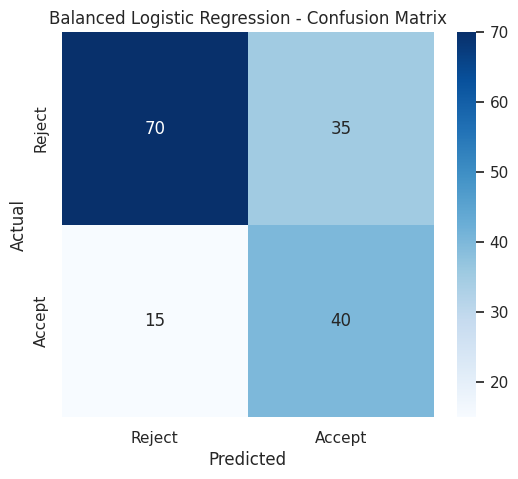

In [133]:
# Visualize the Confusion Matrix

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reject", "Accept"],
    yticklabels=["Reject", "Accept"]
)

plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Observation
The confusion matrix shows the classification performance of the balanced Logistic Regression model. The model gives greater attention to the minority Accept class, improving its ability to identify accepted matches compared with the original model.

In [134]:
# Compare Original and Balanced Models

print("--- MODEL COMPARISON ---")
print(
    "Original Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Balanced Model Accuracy:",
    round(balanced_accuracy * 100, 2),
    "%"
)

print("\nOriginal Accept F1-score: 0.43")
print("Balanced Accept F1-score: 0.62")

--- MODEL COMPARISON ---
Original Model Accuracy: 70.0 %
Balanced Model Accuracy: 68.75 %

Original Accept F1-score: 0.43
Balanced Accept F1-score: 0.62


In [135]:
# Time-Based Feedback Split

feedback_sorted = feedback_ml.sort_values(
    "timestamp"
).copy()

# First 70% = learning period
# Last 30% = testing period
split_index = int(len(feedback_sorted) * 0.70)

feedback_train = feedback_sorted.iloc[:split_index].copy()
feedback_test = feedback_sorted.iloc[split_index:].copy()

print("Learning interactions:", len(feedback_train))
print("Testing interactions:", len(feedback_test))

Learning interactions: 560
Testing interactions: 240


In [136]:
# Learn Personalized Weights from Training Data Only

def learn_user_weights_from_data(user_id, data):
    user_feedback = data[
        data["user_id"] == user_id
    ].copy()

    weights = np.array([0.50, 0.30, 0.20])

    feature_columns = [
        "text_score",
        "mbti_score",
        "location_score"
    ]

    if len(user_feedback) == 0:
        return {
            "text_weight": 0.50,
            "mbti_weight": 0.30,
            "location_weight": 0.20
        }

    accepted = (
        user_feedback[
            user_feedback["action"] == 1
        ][feature_columns].mean() / 100
    )

    rejected = (
        user_feedback[
            user_feedback["action"] == 0
        ][feature_columns].mean() / 100
    )

    if not accepted.isnull().any() and not rejected.isnull().any():

        preference_difference = (
            accepted.values - rejected.values
        )

        weights = weights + (
            0.20 * preference_difference
        )

    weights = np.maximum(weights, 0)

    weights = weights / weights.sum()

    return {
        "text_weight": weights[0],
        "mbti_weight": weights[1],
        "location_weight": weights[2]
    }

In [137]:
# Learn weights using ONLY the first 70%

train_user_weights = {}
for user_id in users["user_id"]:

    train_user_weights[user_id] = (
        learn_user_weights_from_data(
            user_id,
            feedback_train
        )
    )

print(
    "Personalized weights learned from training data for",
    len(train_user_weights),
    "users."
)

Personalized weights learned from training data for 100 users.


In [139]:
# Evaluate Fixed vs Personalized System

evaluation = feedback_test.copy()

# Fixed 50/30/20 compatibility

evaluation["fixed_score"] = (
    0.50 * evaluation["text_score"] +
    0.30 * evaluation["mbti_score"] +
    0.20 * evaluation["location_score"]
)

# Personalized compatibility

personalized_scores = []

for _, row in evaluation.iterrows():

    weights = train_user_weights[row["user_id"]]

    score = (
        weights["text_weight"] * row["text_score"] +
        weights["mbti_weight"] * row["mbti_score"] +
        weights["location_weight"] * row["location_score"]
    )

    personalized_scores.append(score)

evaluation["personalized_score"] = personalized_scores

# Convert scores into Accept/Reject predictions
evaluation["fixed_prediction"] = (
    evaluation["fixed_score"] >= 50
).astype(int)

evaluation["personalized_prediction"] = (
    evaluation["personalized_score"] >= 50
).astype(int)

# Calculate accuracy
fixed_test_accuracy = accuracy_score(
    evaluation["action"],
    evaluation["fixed_prediction"]
)

personalized_test_accuracy = accuracy_score(
    evaluation["action"],
    evaluation["personalized_prediction"]
)

print("========== FINAL EVALUATION ==========")

print(
    "Fixed System Accuracy:",
    round(fixed_test_accuracy * 100, 2),
    "%"
)

print(
    "Personalized System Accuracy:",
    round(personalized_test_accuracy * 100, 2),
    "%"
)

========== FINAL EVALUATION ==========
Fixed System Accuracy: 62.92 %
Personalized System Accuracy: 62.92 %


In [140]:
# Detailed comparison

print("\nFixed System Classification Report:")
print(
    classification_report(
        evaluation["action"],
        evaluation["fixed_prediction"]
    )
)

print("\nPersonalized System Classification Report:")
print(
    classification_report(
        evaluation["action"],
        evaluation["personalized_prediction"]
    )
)


Fixed System Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.97      0.76       149
           1       0.58      0.08      0.14        91

    accuracy                           0.63       240
   macro avg       0.61      0.52      0.45       240
weighted avg       0.61      0.63      0.53       240


Personalized System Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.97      0.76       149
           1       0.58      0.08      0.14        91

    accuracy                           0.63       240
   macro avg       0.61      0.52      0.45       240
weighted avg       0.61      0.63      0.53       240



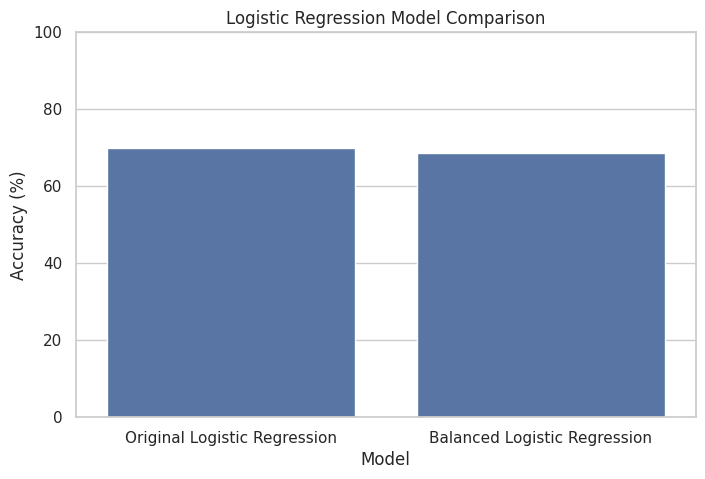

In [141]:
# Model Performance Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy * 100,
        balanced_accuracy * 100
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Logistic Regression Model Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.ylim(0, 100)
plt.show()

## Observation
The original Logistic Regression model achieved 70% accuracy, while the balanced model achieved 68.75% accuracy. Although overall accuracy decreased slightly, balancing the classes substantially improved the model's ability to identify accepted matches, with Accept F1-score increasing from 0.43 to 0.62.

In [142]:
# Final Error Analysis

final_errors = feedback_ml.loc[
    y_test.index[
        y_test.values != balanced_pred
    ]
].copy()

print("========== FINAL ERROR ANALYSIS ==========")
print("Total incorrect predictions:", len(final_errors))
print("Total test samples:", len(y_test))

========== FINAL ERROR ANALYSIS ==========
Total incorrect predictions: 50
Total test samples: 160


In [143]:
# incorrect predictions

error_indices = y_test.index[
    y_test.values != balanced_pred
]

error_details = feedback_ml.loc[
    error_indices,
    [
        "user_id",
        "matched_user_id",
        "text_score",
        "mbti_score",
        "location_score",
        "action"
    ]
].copy()

error_details["predicted_action"] = balanced_pred[
    y_test.values != balanced_pred
]

display(
    error_details.head(10)
)

,user_id,matched_user_id,text_score,mbti_score,location_score,action,predicted_action
789,U099,U084,25.081028,50,30,0,1
321,U041,U036,26.451096,50,30,0,1
311,U039,U012,24.958324,50,30,0,1
192,U025,U070,34.671153,50,30,0,1
460,U058,U036,10.358181,50,100,0,1
738,U093,U013,23.160202,50,30,1,0
77,U010,U041,17.531852,70,30,0,1
670,U084,U015,24.600121,50,30,0,1
745,U094,U026,30.274022,50,100,0,1
713,U090,U080,30.000022,50,30,0,1


In [144]:
# Error Types

false_positives = (
    (y_test == 0) &
    (balanced_pred == 1)
).sum()

false_negatives = (
    (y_test == 1) &
    (balanced_pred == 0)
).sum()

print("False Positives:", false_positives)
print("False Negatives:", false_negatives)

False Positives: 35
False Negatives: 15


## Interpretation

False Positive:

The model predicted Accept, but the actual feedback was Reject.

False Negative:

The model predicted Reject, but the actual feedback was Accept.

## Observation
The final error analysis identified 50 incorrect predictions out of 160 test samples. Both false positives and false negatives are present. False positives occur when the model predicts that a match will be accepted although the recorded feedback is rejection, while false negatives occur when the model fails to identify an accepted match. These errors are expected because compatibility depends on multiple factors and the dataset is synthetically generated. The analysis provides useful insight into where the feedback model can be improved.

In [145]:
# Save Final Models

import joblib
joblib.dump(
    tfidf_vectorizer,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    feedback_model_final,
    "feedback_model.pkl"
)

joblib.dump(
    train_user_weights,
    "user_adaptive_weights.pkl"
)
print("All final models saved successfully!")

All final models saved successfully!


In [146]:
# Save Final Datasets

users.to_csv(
    "users.csv",
    index=False
)

feedback.to_csv(
    "feedback.csv",
    index=False
)

feedback_ml.to_csv(
    "feedback_ml.csv",
    index=False
)

print("All final datasets saved successfully!")

All final datasets saved successfully!


In [148]:
# Verify Final Project Files

import os

project_files = [
    "users.csv",
    "feedback.csv",
    "feedback_ml.csv",
    "tfidf_vectorizer.pkl",
    "feedback_model.pkl",
    "user_adaptive_weights.pkl"
]

print("========== FINAL PROJECT FILES ==========")

for file_name in project_files:

    if os.path.exists(file_name):
        size_kb = os.path.getsize(file_name) / 1024
        print(f"✓ {file_name} ({size_kb:.2f} KB)")
    else:
        print(f"✗ {file_name} — NOT FOUND")

========== FINAL PROJECT FILES ==========
✓ users.csv (123.77 KB)
✓ feedback.csv (25.04 KB)
✓ feedback_ml.csv (44.41 KB)
✓ tfidf_vectorizer.pkl (9.33 KB)
✓ feedback_model.pkl (1.17 KB)
✓ user_adaptive_weights.pkl (7.37 KB)


In [149]:
from google.colab import files

files.download("users.csv")
files.download("feedback.csv")
files.download("feedback_ml.csv")
files.download("tfidf_vectorizer.pkl")
files.download("feedback_model.pkl")
files.download("user_adaptive_weights.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>